In [ ]:
%pip install pandas matplotlib

  Using cached pandas-3.0.3-cp312-cp312-win_amd64.whl.metadata (19 kB)
   ---------------------------------------- 0.0/9.8 MB ? eta -:--:--
   ------------- -------------------------- 3.4/9.8 MB 16.8 MB/s eta 0:00:01
   --------------------------- ------------ 6.8/9.8 MB 17.5 MB/s eta 0:00:01
   ---------------------------------------- 9.8/9.8 MB 16.4 MB/s eta 0:00:00
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   -------------- ------------------------- 3.4/9.3 MB 15.5 MB/s eta 0:00:01
   ------------------------------ --------- 7.1/9.3 MB 16.8 MB/s eta 0:00:01
   ---------------------------------------- 9.3/9.3 MB 16.6 MB/s eta 0:00:00
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ---------------------------------------- 2.3/2.3 MB 16.6 MB/s eta 0:00:00
   ---------------------------------------- 0.0/12.4 MB ? eta -:--:--
   ----------- ---------------------------- 3.7/12.4 MB 18.1 MB/s eta 0:00:01
   ----------------------- --------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [11]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import display

history_dir = Path("../output/analytics_logs")
history_files = sorted(history_dir.glob("run_*.json"))

if not history_files:
    raise FileNotFoundError(f"No analytics history files found in {history_dir}")

run_rows = []
for path in history_files:
    data = json.loads(path.read_text(encoding="utf-8"))
    summary = dict(data["summary"] )
    summary["history_file"] = path.name
    run_rows.append(summary)

run_history = pd.DataFrame(run_rows).sort_values("generated_at").reset_index(drop=True)
latest_data = json.loads(history_files[-1].read_text(encoding="utf-8"))
latest_tasks = pd.DataFrame(latest_data["tasks"])
latest_run = run_history.iloc[-1]
previous_run = run_history.iloc[-2] if len(run_history) > 1 else None

run_history

,run_id,generated_at,tasks,pipeline_elapsed_seconds,prompt_tokens,completion_tokens,total_tokens,average_model_elapsed_seconds,history_file
0,4a008ab4716a42edab0cd62baf490047,2026-07-08T02:38:08.123875+00:00,8,26.1418,1756,962,2718,1.5080,run_4a008ab4716a42edab0cd62baf490047.json
1,3a0cb60c01b8488a80db9c74cbd6946d,2026-07-08T02:50:15.450128+00:00,8,31.1775,554,961,1515,1.8317,run_3a0cb60c01b8488a80db9c74cbd6946d.json


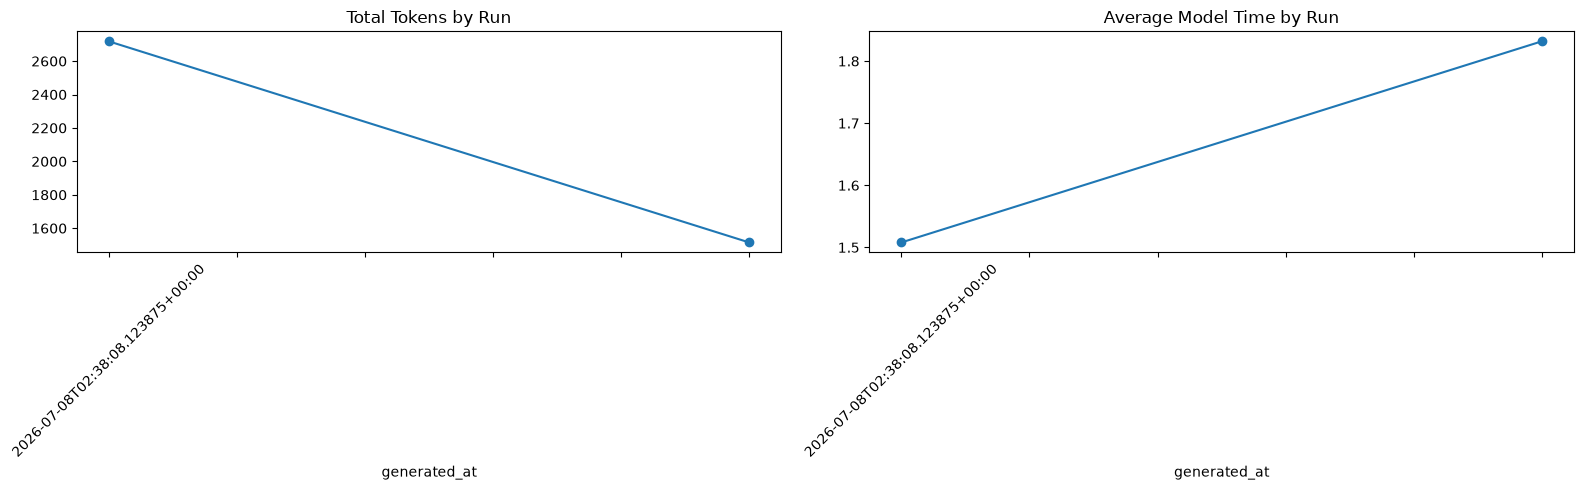

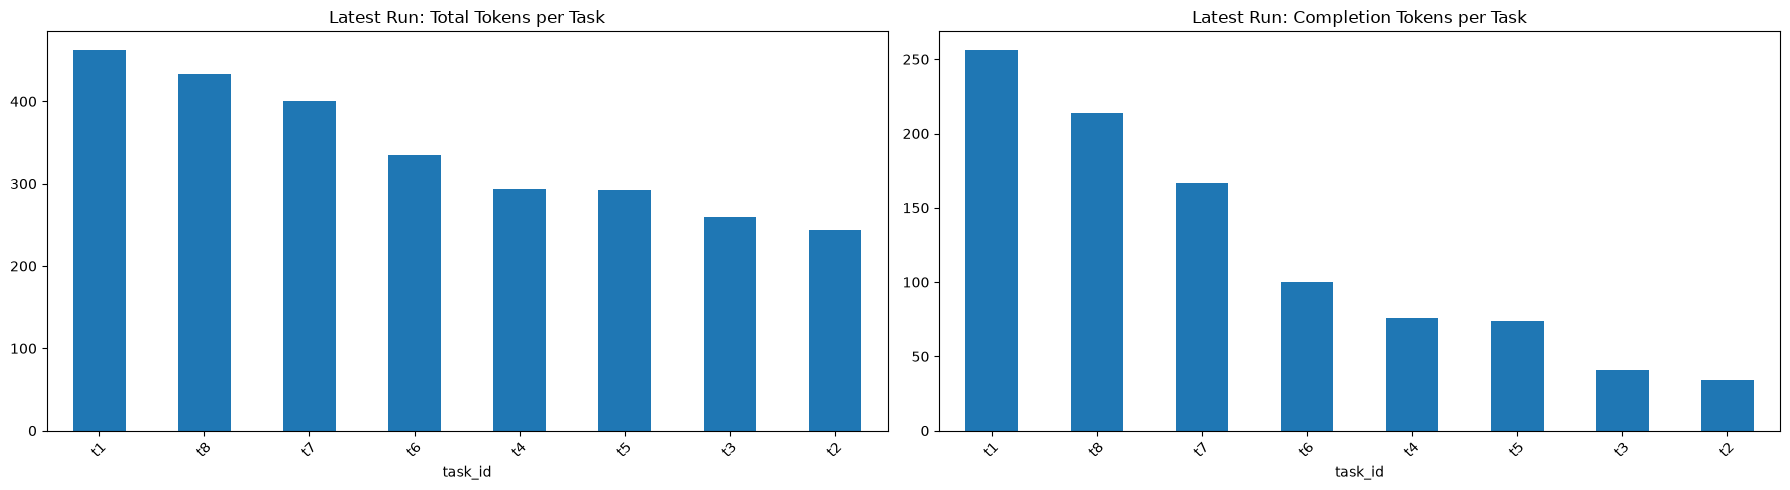

In [12]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

run_history.plot(x="generated_at", y="total_tokens", ax=axes[0], marker="o", legend=False, title="Total Tokens by Run")
run_history.plot(x="generated_at", y="average_model_elapsed_seconds", ax=axes[1], marker="o", legend=False, title="Average Model Time by Run")

for axis in axes:
    axis.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

latest_tasks.sort_values("total_tokens", ascending=False).plot.bar(
    x="task_id",
    y="total_tokens",
    ax=axes[0],
    legend=False,
    title="Latest Run: Total Tokens per Task",
)

latest_tasks.sort_values("total_tokens", ascending=False).plot.bar(
    x="task_id",
    y="completion_tokens",
    ax=axes[1],
    legend=False,
    title="Latest Run: Completion Tokens per Task",
)

for axis in axes:
    axis.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

Latest run:


,latest
tasks,8
total_tokens,1515
prompt_tokens,554
completion_tokens,961
pipeline_elapsed_seconds,31.1775
average_model_elapsed_seconds,1.8317
generated_at,2026-07-08T02:50:15.450128+00:00
history_file,run_3a0cb60c01b8488a80db9c74cbd6946d.json
run_id,3a0cb60c01b8488a80db9c74cbd6946d


Previous run:


,previous
tasks,8
total_tokens,2718
prompt_tokens,1756
completion_tokens,962
pipeline_elapsed_seconds,26.1418
average_model_elapsed_seconds,1.508
generated_at,2026-07-08T02:38:08.123875+00:00
history_file,run_4a008ab4716a42edab0cd62baf490047.json
run_id,4a008ab4716a42edab0cd62baf490047


Run comparison:


,latest,previous,delta
total_tokens,1515,2718,-1203
prompt_tokens,554,1756,-1202
completion_tokens,961,962,-1
pipeline_elapsed_seconds,31.1775,26.1418,5.0357
average_model_elapsed_seconds,1.8317,1.508,0.3237


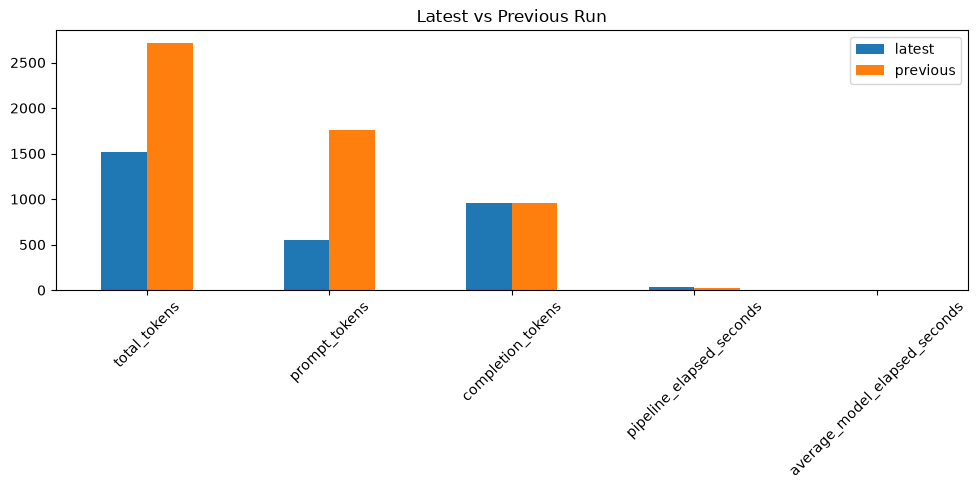

Latest task breakdown:


,task_id,category,confidence,method,chosen_model,reason,model_elapsed_seconds,prompt_tokens,completion_tokens,total_tokens
0,t1,factual_knowledge,0.92,ai_router,accounts/fireworks/models/minimax-m3,high_confidence_choose_smallest,1.9676,206,256,462
7,t8,code_generation,0.99,ai_router,accounts/fireworks/models/minimax-m3,high_confidence_choose_smallest,2.7655,219,214,433
6,t7,logical_deductive_reasoning,0.95,ai_router,accounts/fireworks/models/minimax-m3,high_confidence_choose_smallest,1.2291,233,167,400
5,t6,code_debugging,0.99,ai_router,accounts/fireworks/models/minimax-m3,high_confidence_choose_smallest,1.1206,235,100,335
3,t4,text_summarisation,0.99,ai_router,accounts/fireworks/models/minimax-m3,high_confidence_choose_smallest,1.1554,217,76,293
4,t5,named_entity_recognition,0.99,ai_router,accounts/fireworks/models/minimax-m3,high_confidence_choose_smallest,1.4336,218,74,292
2,t3,sentiment_classification,0.99,ai_router,accounts/fireworks/models/minimax-m3,high_confidence_choose_smallest,1.4336,218,41,259
1,t2,mathematical_reasoning,0.99,ai_router,accounts/fireworks/models/minimax-m3,high_confidence_choose_smallest,0.9589,210,34,244


In [13]:
compare_cols = [
    "tasks",
    "total_tokens",
    "prompt_tokens",
    "completion_tokens",
    "pipeline_elapsed_seconds",
    "average_model_elapsed_seconds",
    "generated_at",
    "history_file",
    "run_id",
]

print("Latest run:")
display(latest_run[compare_cols].to_frame(name="latest"))

if previous_run is not None:
    print("Previous run:")
    display(previous_run[compare_cols].to_frame(name="previous"))

    comparison = pd.DataFrame({
        "latest": latest_run[["total_tokens", "prompt_tokens", "completion_tokens", "pipeline_elapsed_seconds", "average_model_elapsed_seconds"]],
        "previous": previous_run[["total_tokens", "prompt_tokens", "completion_tokens", "pipeline_elapsed_seconds", "average_model_elapsed_seconds"]],
    })
    comparison["delta"] = comparison["latest"] - comparison["previous"]
    print("Run comparison:")
    display(comparison)

    fig, ax = plt.subplots(figsize=(10, 5))
    comparison[["latest", "previous"]].plot.bar(ax=ax, title="Latest vs Previous Run")
    ax.tick_params(axis="x", rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("Only one run is available, so there is no previous run to compare.")

print("Latest task breakdown:")
display(latest_tasks.sort_values("total_tokens", ascending=False))